In [61]:
import pandas as pd
import numpy as np
import dask.dataframe as dd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import os
from glob import glob
from dask.array.image import imread
# image_location = "/data/jfreuden/SomeSkyImages/"
# enriched_df_location = "/data/jfreuden/allsky-light-pollution-simple/data/enriched.parquet"
image_location = "/home/rainybyte/SomeSkyImages/"
enriched_df_location = "/home/rainybyte/Downloads/enriched_df.parquet"

In [62]:
def _weighted_fit_line(x, y, yerr):
    """
    Return a weighted linear fit and confidence band when possible.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    yerr = np.asarray(yerr, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y) & np.isfinite(yerr) & (yerr > 0)
    x = x[valid]
    y = y[valid]
    yerr = yerr[valid]

    if len(x) == 0:
        return None

    if len(x) == 1 or np.unique(x).size == 1:
        beta = np.array([0.0, y[0]], dtype=float)
        x_grid = np.linspace(x[0] - 1.0, x[0] + 1.0, 2)
        y_grid = np.full_like(x_grid, y[0], dtype=float)
        return {
            "x": x,
            "y": y,
            "yerr": yerr,
            "beta": beta,
            "x_grid": x_grid,
            "y_grid": y_grid,
            "y_lower": y_grid,
            "y_upper": y_grid,
            "m": beta[0],
            "b": beta[1],
        }

    w = 1.0 / np.square(yerr)
    X = np.column_stack([x, np.ones_like(x)])

    sqrt_w = np.sqrt(w)
    Xw = X * sqrt_w[:, None]
    yw = y * sqrt_w
    beta, *_ = np.linalg.lstsq(Xw, yw, rcond=None)
    m, b = beta

    x_grid = np.linspace(x.min(), x.max(), 400)
    X_grid = np.column_stack([x_grid, np.ones_like(x_grid)])
    y_grid = X_grid @ beta

    y_fit_obs = X @ beta
    dof = max(len(x) - 2, 1)
    s2 = np.sum(w * (y - y_fit_obs) ** 2) / dof

    XtWX = X.T @ (w[:, None] * X)
    cov_beta = s2 * np.linalg.pinv(XtWX)

    y_var_grid = np.sum((X_grid @ cov_beta) * X_grid, axis=1)
    y_se_grid = np.sqrt(np.maximum(y_var_grid, 0.0))

    z = 1.96
    y_lower = y_grid - z * y_se_grid
    y_upper = y_grid + z * y_se_grid

    return {
        "x": x,
        "y": y,
        "yerr": yerr,
        "beta": beta,
        "x_grid": x_grid,
        "y_grid": y_grid,
        "y_lower": y_lower,
        "y_upper": y_upper,
        "m": m,
        "b": b,
    }

alias_labels = {
    "D": "Nightly",
    "W": "Weekly",
    "M": "Monthly",
    "Q": "Quarterly",
    "A": "Yearly",
    "H": "Hourly",
}

def plot_brightness(input_df, title_suffix=None, period="D", ax=None):
    df = input_df[["timestamp", "image_mean", "image_std", "exposure"]].copy()

    plot_df = df.groupby(df["timestamp"].dt.to_period(period)).agg(
        mean_image_mean=("image_mean", "mean"),
        n=("image_mean", "size"),
        pooled_image_std=("image_std", lambda s: np.sqrt(np.mean(s ** 2))),
    ).reset_index()

    plot_df["date"] = plot_df["timestamp"].dt.to_timestamp()
    plot_df["error"] = plot_df["pooled_image_std"] / np.sqrt(plot_df["n"])
    plot_df = plot_df.drop(columns=["timestamp"]).dropna(subset=["date", "mean_image_mean", "error"]).sort_values("date")

    x = mdates.date2num(np.array(plot_df["date"]))
    y = plot_df["mean_image_mean"].to_numpy(dtype=float)
    yerr = plot_df["error"].to_numpy(dtype=float)

    fit = _weighted_fit_line(x, y, yerr)
    if fit is None:
        print(f"No valid data to plot for {title_suffix or 'this dataset'}.")
        return

    dates_grid = mdates.num2date(fit["x_grid"])
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 5))
    else:
        fig = ax.figure

    ax.errorbar(
        plot_df["date"], y, yerr=yerr,
        fmt="o", markersize=3, capsize=3, alpha=0.5,
        label="Daily mean ± error",
    )

    ax.plot(
        dates_grid, fit["y_grid"],
        color="red", linewidth=2,
        label=("Constant fit" if len(fit["x"]) == 1 else f"Weighted fit: y = {fit['m']:.4g}x + {fit['b']:.4g}"),
    )

    if len(fit["x"]) > 1:
        ax.fill_between(
            dates_grid, fit["y_lower"], fit["y_upper"],
            color="red", alpha=0.2, label="95% confidence band",
        )

    ax.set_xlabel("Date")
    ax.set_ylabel("Avg daily image brightness")
    suffix = "" if title_suffix == "" or title_suffix is None else f" ({title_suffix})"
    ax.set_title(f"{alias_labels[period]} image brightness" + suffix)
    ax.legend()
    fig.tight_layout()
    return ax


def plot_exposure(input_df, title_suffix=None, period="D", ax=None):
    df = input_df[["timestamp", "image_mean", "image_std", "exposure"]].copy()

    exposure_daily = df.groupby(df["timestamp"].dt.to_period(period)).agg(
        mean_exposure=("exposure", "mean"),
        n=("exposure", "size"),
        exposure_std=("exposure", "std"),
    ).reset_index()

    exposure_daily["date"] = exposure_daily["timestamp"].dt.to_timestamp()
    exposure_daily["error"] = exposure_daily["exposure_std"] / np.sqrt(exposure_daily["n"])
    exposure_daily = exposure_daily.drop(columns=["timestamp"]).dropna(subset=["date", "mean_exposure"]).sort_values("date")

    plot_df = exposure_daily.dropna(subset=["error"])
    x = mdates.date2num(np.array(plot_df["date"]))
    y = plot_df["mean_exposure"].to_numpy(dtype=float)
    yerr = plot_df["error"].to_numpy(dtype=float)

    fit = _weighted_fit_line(x, y, yerr)
    if fit is None:
        print(f"No valid data to plot for {title_suffix or 'this dataset'}.")
        return

    dates_grid = mdates.num2date(fit["x_grid"])
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 5))
    else:
        fig = ax.figure

    ax.errorbar(
        plot_df["date"], y, yerr=yerr,
        fmt="o", markersize=3, capsize=3, alpha=0.6,
        label="Nightly mean exposure ± error",
    )

    ax.plot(
        dates_grid, fit["y_grid"],
        color="red", linewidth=2,
        label=("Constant fit" if len(fit["x"]) == 1 else f"Weighted fit: y = {fit['m']:.4g}x + {fit['b']:.4g}"),
    )

    if len(fit["x"]) > 1:
        ax.fill_between(
            dates_grid, fit["y_lower"], fit["y_upper"],
            color="red", alpha=0.2, label="95% confidence band",
        )

    ax.set_xlabel("Date")
    ax.set_ylabel("Mean nightly exposure time")
    suffix = "" if title_suffix == "" or title_suffix is None else f" ({title_suffix})"
    ax.set_title(f"{alias_labels[period]} mean exposure time" + suffix)
    ax.legend()
    fig.tight_layout()
    return ax


def plot_luminous_flux(input_df, title_suffix=None, period="D", ax=None):
    df = input_df[["timestamp", "image_mean", "image_std", "exposure"]].copy()
    df = df.assign(luminous_flux=df["image_mean"] / df["exposure"])
    df = df.dropna(subset=["timestamp", "image_mean", "image_std", "exposure", "luminous_flux"])

    sigma_exposure = 0.0
    df["luminous_flux_error"] = np.sqrt(
        (df["image_std"] / df["exposure"])**2 +
        ((df["image_mean"] * sigma_exposure) / (df["exposure"]**2))**2
    )

    daily = df.groupby(df["timestamp"].dt.to_period(period)).agg(
        mean_luminous_flux=("luminous_flux", "mean"),
        n=("luminous_flux", "size"),
        flux_error_rss=("luminous_flux_error", lambda s: np.sqrt(np.sum(np.square(s))) / len(s)),
    ).reset_index()

    daily["date"] = daily["timestamp"].dt.to_timestamp()
    daily["error"] = daily["flux_error_rss"]
    daily = daily.drop(columns=["timestamp"]).dropna(subset=["date", "mean_luminous_flux"]).sort_values("date")

    plot_df = daily.dropna(subset=["error"])
    x = mdates.date2num(np.array(plot_df["date"]))
    y = plot_df["mean_luminous_flux"].to_numpy(dtype=float)
    yerr = plot_df["error"].to_numpy(dtype=float)

    fit = _weighted_fit_line(x, y, yerr)
    if fit is None:
        print(f"No valid data to plot for {title_suffix or 'this dataset'}.")
        return

    dates_grid = mdates.num2date(fit["x_grid"])
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 5))
    else:
        fig = ax.figure

    ax.errorbar(
        plot_df["date"], y, yerr=yerr,
        fmt="o", markersize=3, capsize=3, alpha=0.6,
        label="Nightly mean luminous flux ± error",
    )

    ax.plot(
        dates_grid, fit["y_grid"],
        color="red", linewidth=2,
        label=("Constant fit" if len(fit["x"]) == 1 else f"Weighted fit: y = {fit['m']:.4g}x + {fit['b']:.4g}"),
    )

    if len(fit["x"]) > 1:
        ax.fill_between(
            dates_grid, fit["y_lower"], fit["y_upper"],
            color="red", alpha=0.2, label="95% confidence band",
        )

    ax.set_xlabel("Date")
    ax.set_ylabel("Mean luminous flux")
    suffix = "" if title_suffix == "" or title_suffix is None else f" ({title_suffix})"
    ax.set_title(f"{alias_labels[period]} luminous flux" + suffix)
    ax.legend()
    fig.tight_layout()
    return ax

In [63]:
enriched_df = pd.read_parquet(enriched_df_location)
enriched_df["image_paths"] = enriched_df["image_paths"].str.replace("/data/jfreuden/SomeSkyImages/", "/home/rainybyte/SomeSkyImages/")

<Axes: title={'center': 'Nightly luminous flux (Full Dataset)'}, xlabel='Date', ylabel='Mean luminous flux'>

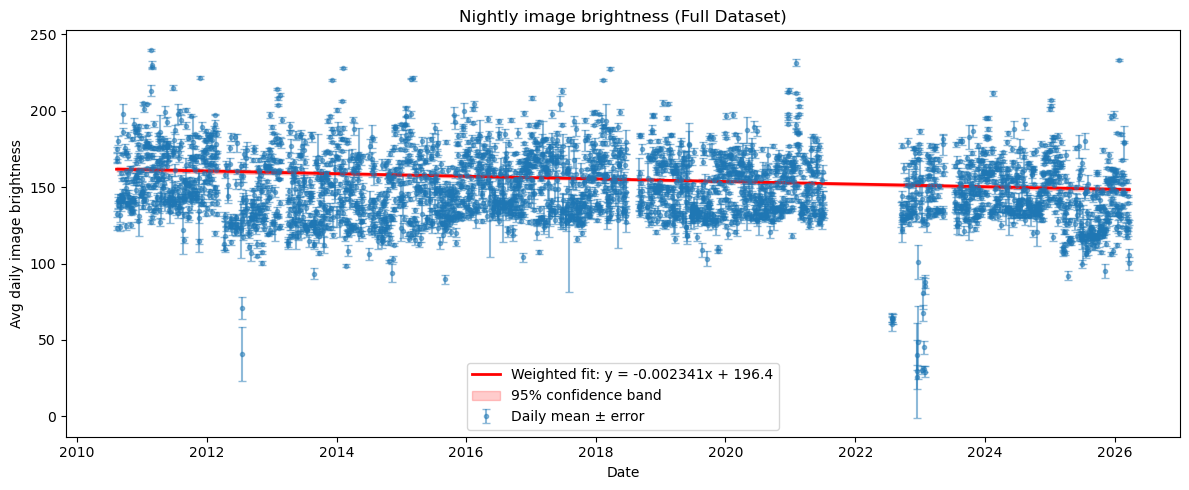

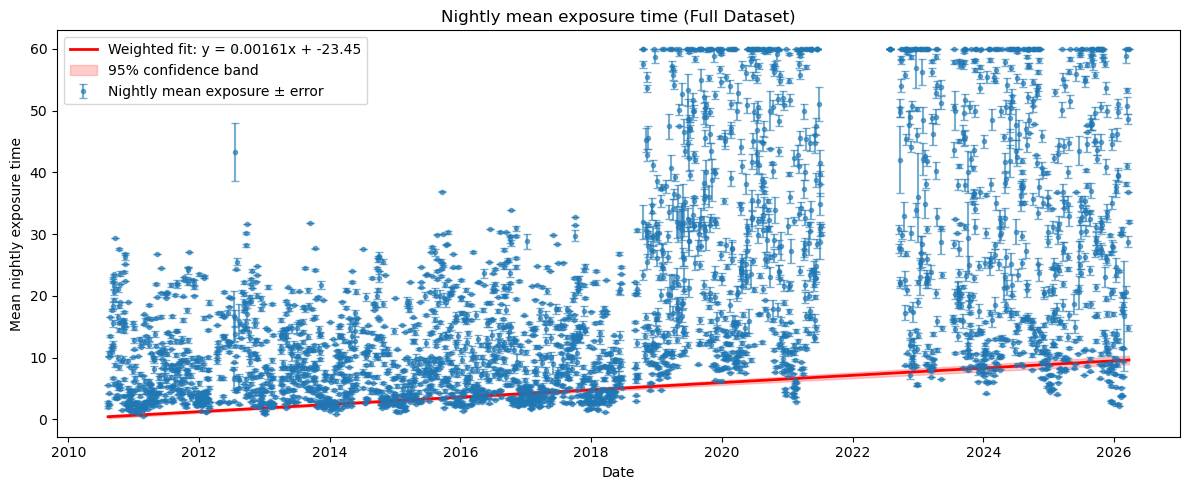

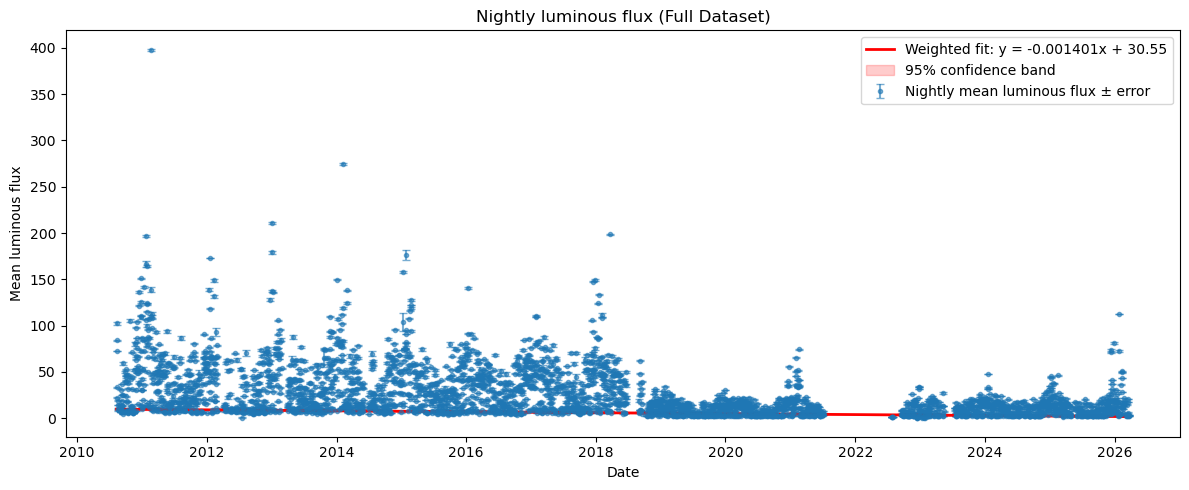

In [64]:
plot_brightness(enriched_df, "Full Dataset")
plot_exposure(enriched_df, "Full Dataset")
plot_luminous_flux(enriched_df, "Full Dataset")

In [65]:
recent_df = enriched_df[
        (pd.to_datetime(enriched_df["date"], format="%Y/%m/%d", errors="coerce").dt.year >= 2022)
]

<Axes: title={'center': 'Nightly luminous flux (July 2022 - Present)'}, xlabel='Date', ylabel='Mean luminous flux'>

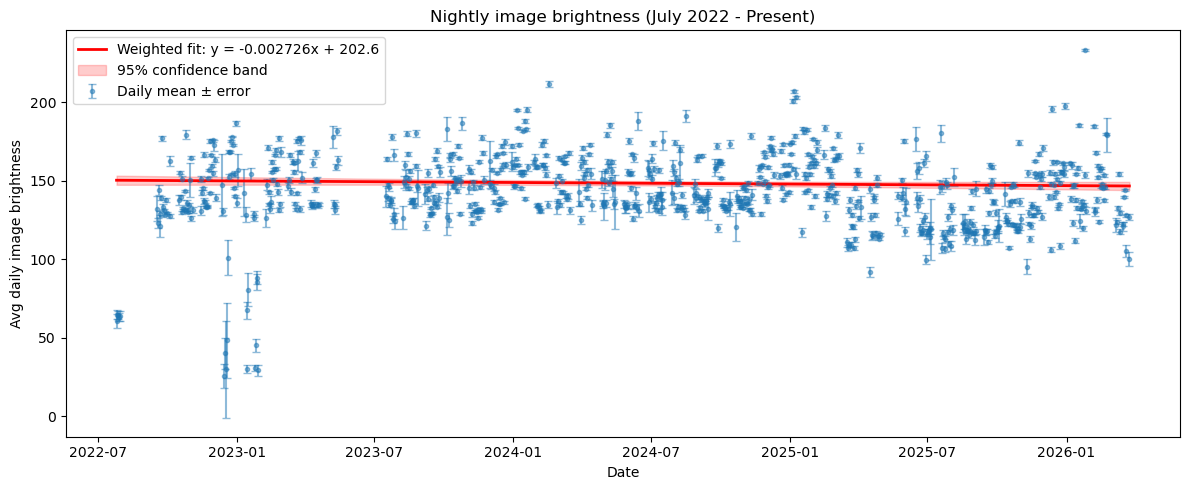

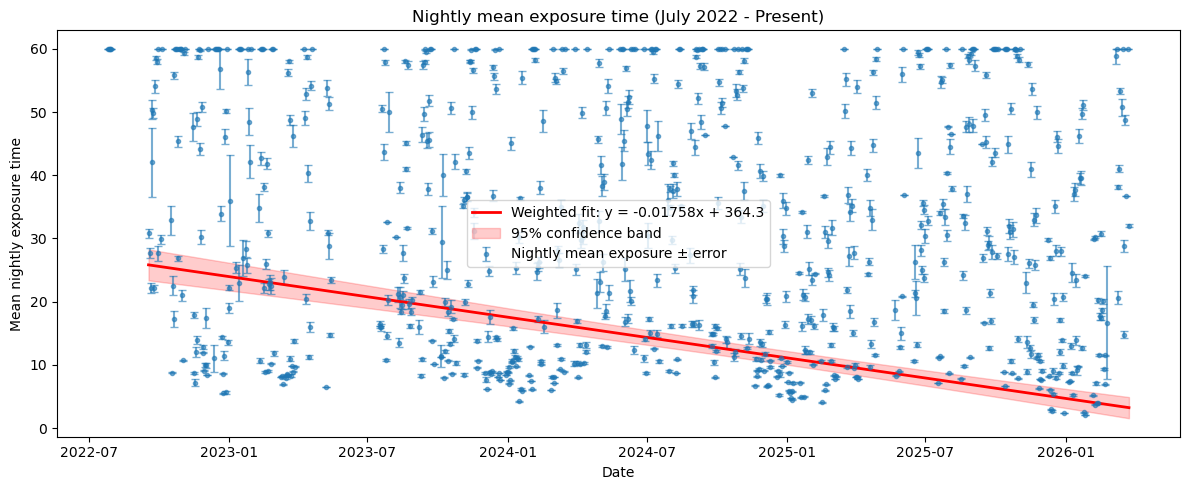

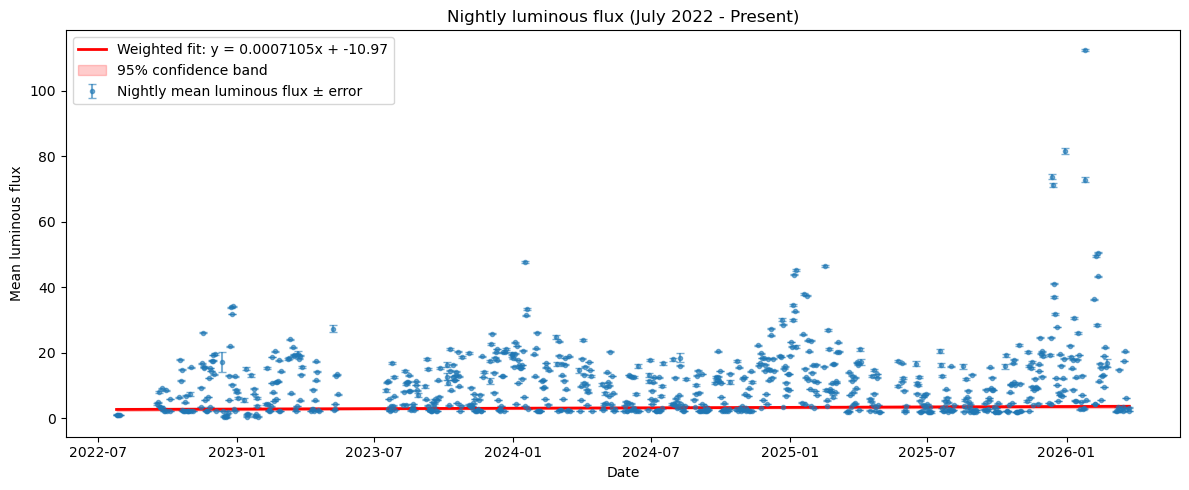

In [66]:
plot_brightness(recent_df, "July 2022 - Present")
plot_exposure(recent_df, "July 2022 - Present")
plot_luminous_flux(recent_df, "July 2022 - Present")

In [67]:
enriched_df

,date,time,exposure,filename,source_file,timestamp,image_paths,image_mean,image_sum,image_min,image_max,image_std,image_medians
8,2010/08/11,22:38:00,2.7883,000021274,2010-08.parquet,2010-08-11 22:38:00,/home/rainybyte/SomeSkyImages/2010-08/AllSkyIm...,157.789822,19822662,105,242,29.416727,156.0
9,2010/08/11,22:39:17,2.4769,000021275,2010-08.parquet,2010-08-11 22:39:17,/home/rainybyte/SomeSkyImages/2010-08/AllSkyIm...,159.858382,20082529,102,242,25.961395,158.0
10,2010/08/11,22:40:17,2.4769,000021276,2010-08.parquet,2010-08-11 22:40:17,/home/rainybyte/SomeSkyImages/2010-08/AllSkyIm...,163.385713,20525657,115,240,25.684782,161.0
11,2010/08/11,22:41:34,2.4769,000021277,2010-08.parquet,2010-08-11 22:41:34,/home/rainybyte/SomeSkyImages/2010-08/AllSkyIm...,166.985608,20977901,117,245,28.818942,163.0
12,2010/08/11,22:42:34,2.4769,000021278,2010-08.parquet,2010-08-11 22:42:34,/home/rainybyte/SomeSkyImages/2010-08/AllSkyIm...,158.146314,19867447,99,248,34.864647,154.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,2026/03/25,05:40:08,32.0241,000422467,2026-03.parquet,2026-03-25 05:40:08,/home/rainybyte/SomeSkyImages/2026-03/AllSkyIm...,103.790141,13038844,51,221,19.991641,102.0
5,2026/03/25,05:40:41,32.0241,000422468,2026-03.parquet,2026-03-25 05:40:41,/home/rainybyte/SomeSkyImages/2026-03/AllSkyIm...,103.978412,13062496,57,235,19.158357,102.0
6,2026/03/25,05:41:34,36.3559,000422469,2026-03.parquet,2026-03-25 05:41:34,/home/rainybyte/SomeSkyImages/2026-03/AllSkyIm...,107.699698,13529990,56,232,20.021279,105.0
7,2026/03/25,05:42:11,36.3559,000422470,2026-03.parquet,2026-03-25 05:42:11,/home/rainybyte/SomeSkyImages/2026-03/AllSkyIm...,107.371680,13488782,59,253,21.015155,105.0


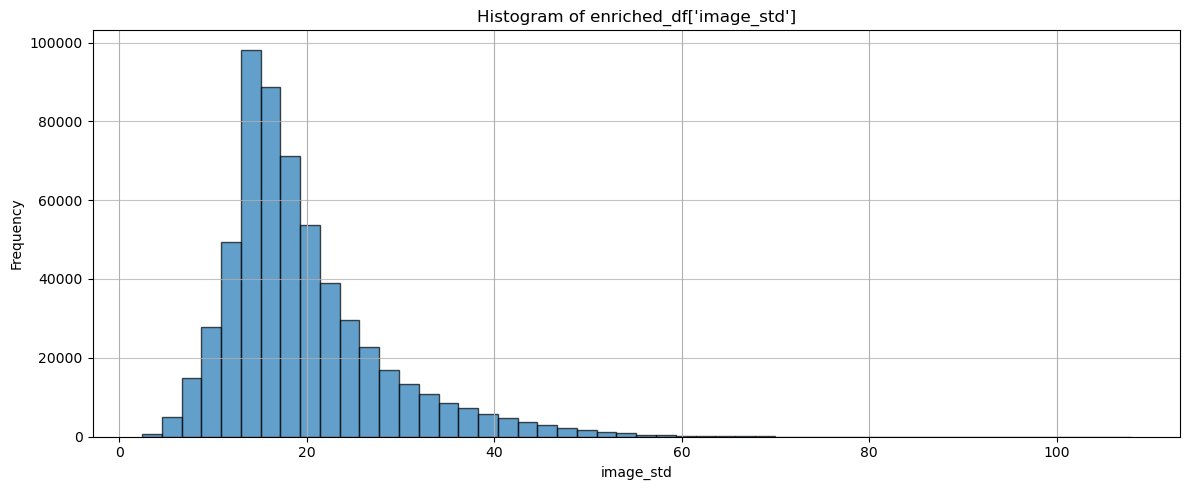

In [68]:
fig, ax = plt.subplots(figsize=(12, 5))
enriched_df['image_std'].hist(ax=ax, bins=50, edgecolor='black', alpha=0.7)
plt.title('Histogram of enriched_df[\'image_std\']')
plt.xlabel('image_std')
plt.ylabel('Frequency')
ax.grid(axis='y', alpha=0.75)
fig.tight_layout()

In [69]:
date_dt = pd.to_datetime(enriched_df["date"], format="%Y/%m/%d", errors="coerce")

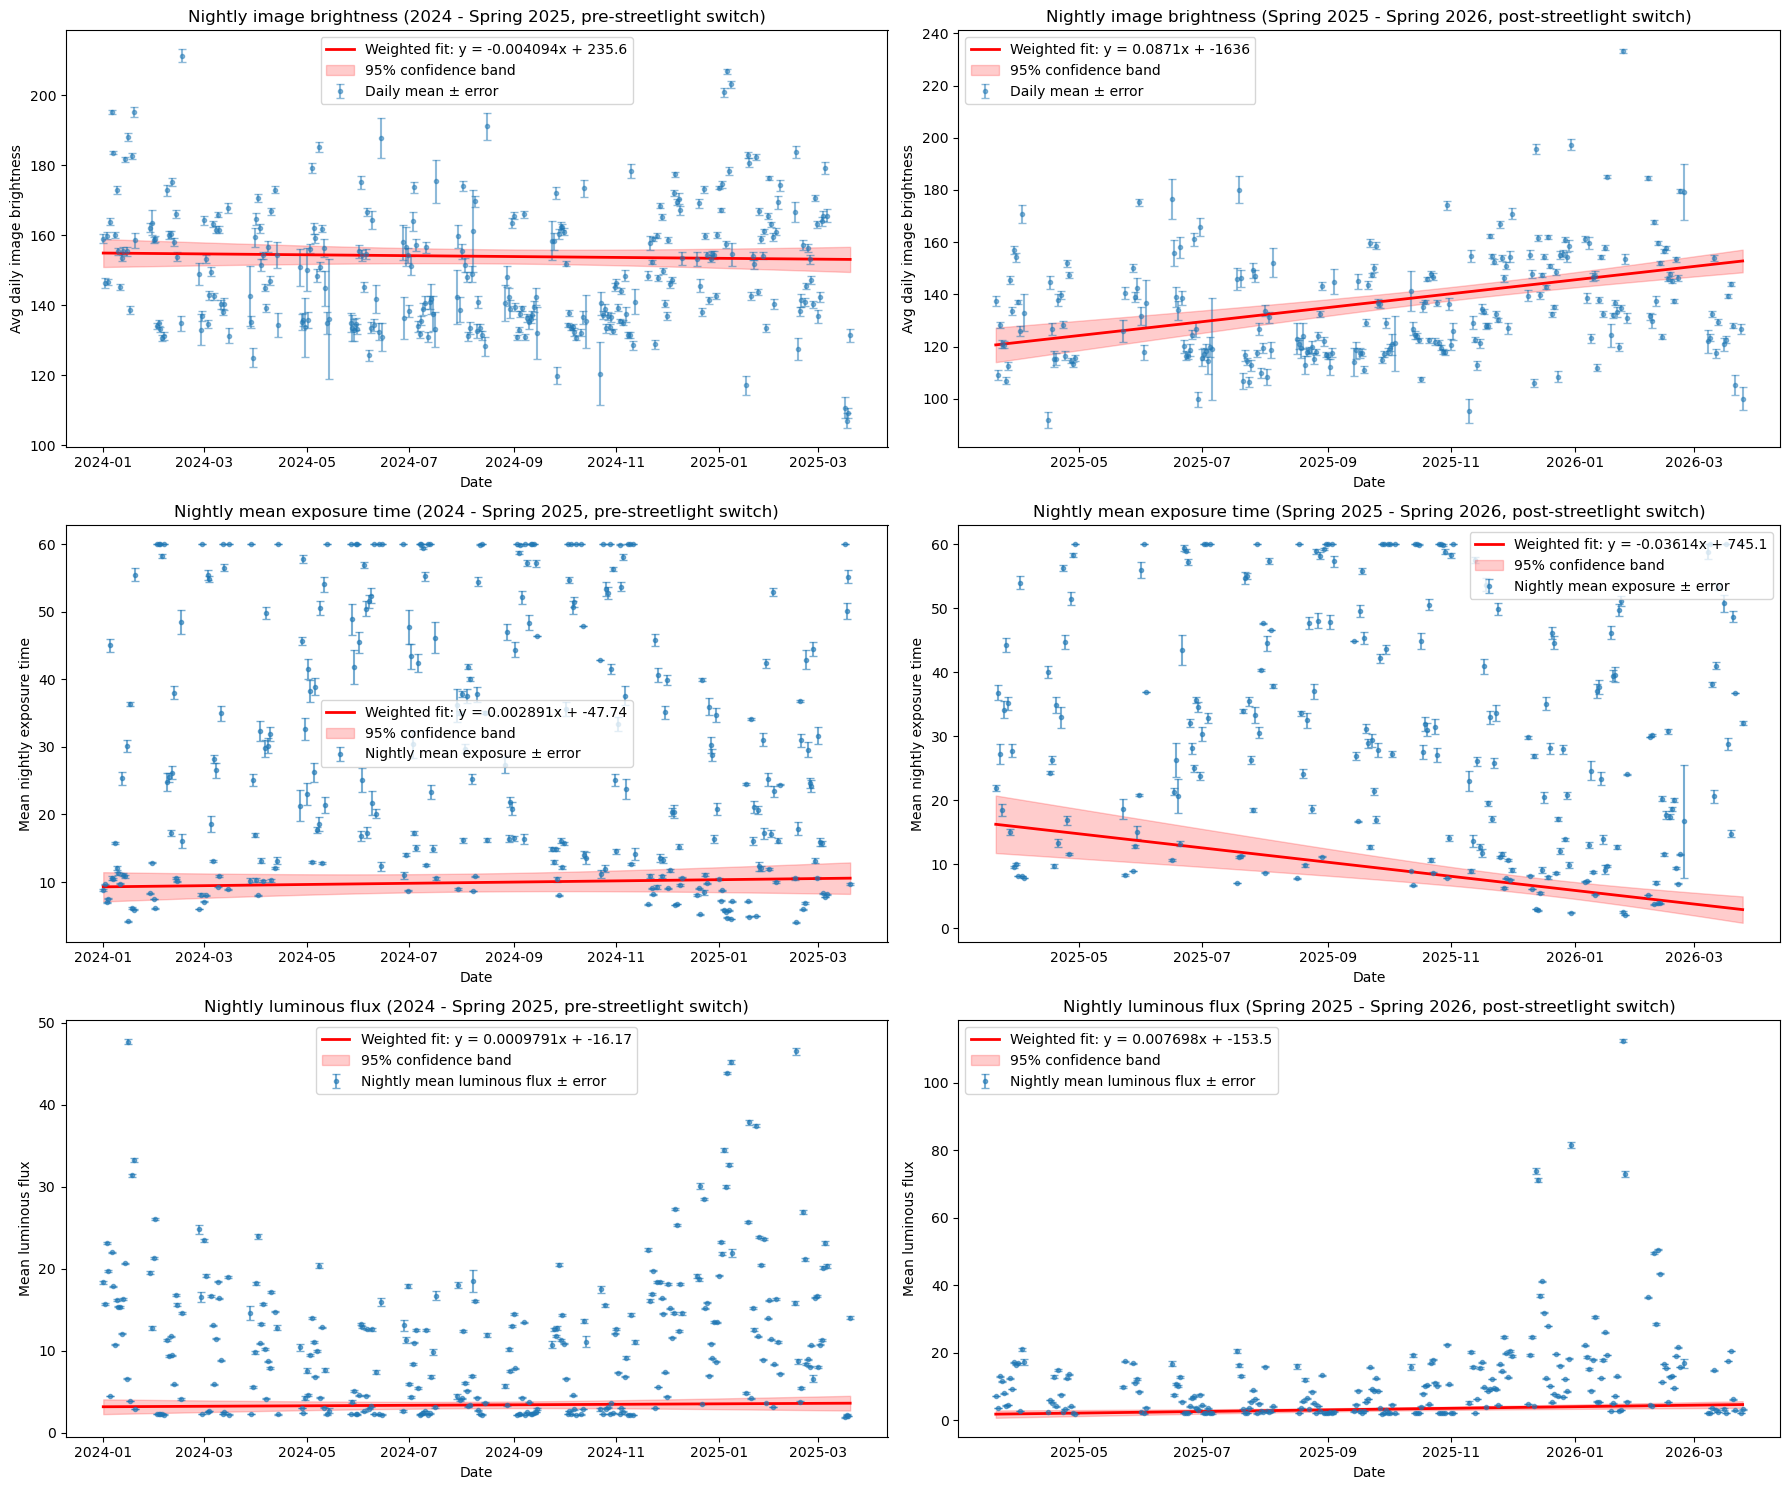

In [70]:
import ipywidgets as widgets




def plot_graph(split_date = "2025-03-21", period="D"):
    fig, axes = plt.subplots(3, 2, figsize=(18, 15), sharex=False)

    preswitch_df = enriched_df[
        (date_dt.dt.year >= 2024) &
        (date_dt < pd.to_datetime(split_date))
    ]
    postswitch_df = enriched_df[
        # (date_dt.dt.year >= 2025)
        (date_dt >= pd.to_datetime(split_date))
    ]

    plot_brightness(preswitch_df, "2024 - Spring 2025, pre-streetlight switch", period, ax=axes[0, 0])
    plot_exposure(preswitch_df, "2024 - Spring 2025, pre-streetlight switch", period, ax=axes[1, 0])
    plot_luminous_flux(preswitch_df, "2024 - Spring 2025, pre-streetlight switch", period, ax=axes[2, 0])
    plot_brightness(postswitch_df, "Spring 2025 - Spring 2026, post-streetlight switch", period, ax=axes[0, 1])
    plot_exposure(postswitch_df, "Spring 2025 - Spring 2026, post-streetlight switch", period, ax=axes[1, 1])
    _ = plot_luminous_flux(postswitch_df, "Spring 2025 - Spring 2026, post-streetlight switch", period, ax=axes[2, 1])
    plt.tight_layout()

# datepick = widgets.DatePicker(description='Date:', value=pd.to_datetime('2025-03-21'))


# widgets.interactive(plot_graph, density=datepick.value.strftime("%Y-%m-%d"))
plot_graph(period="D")



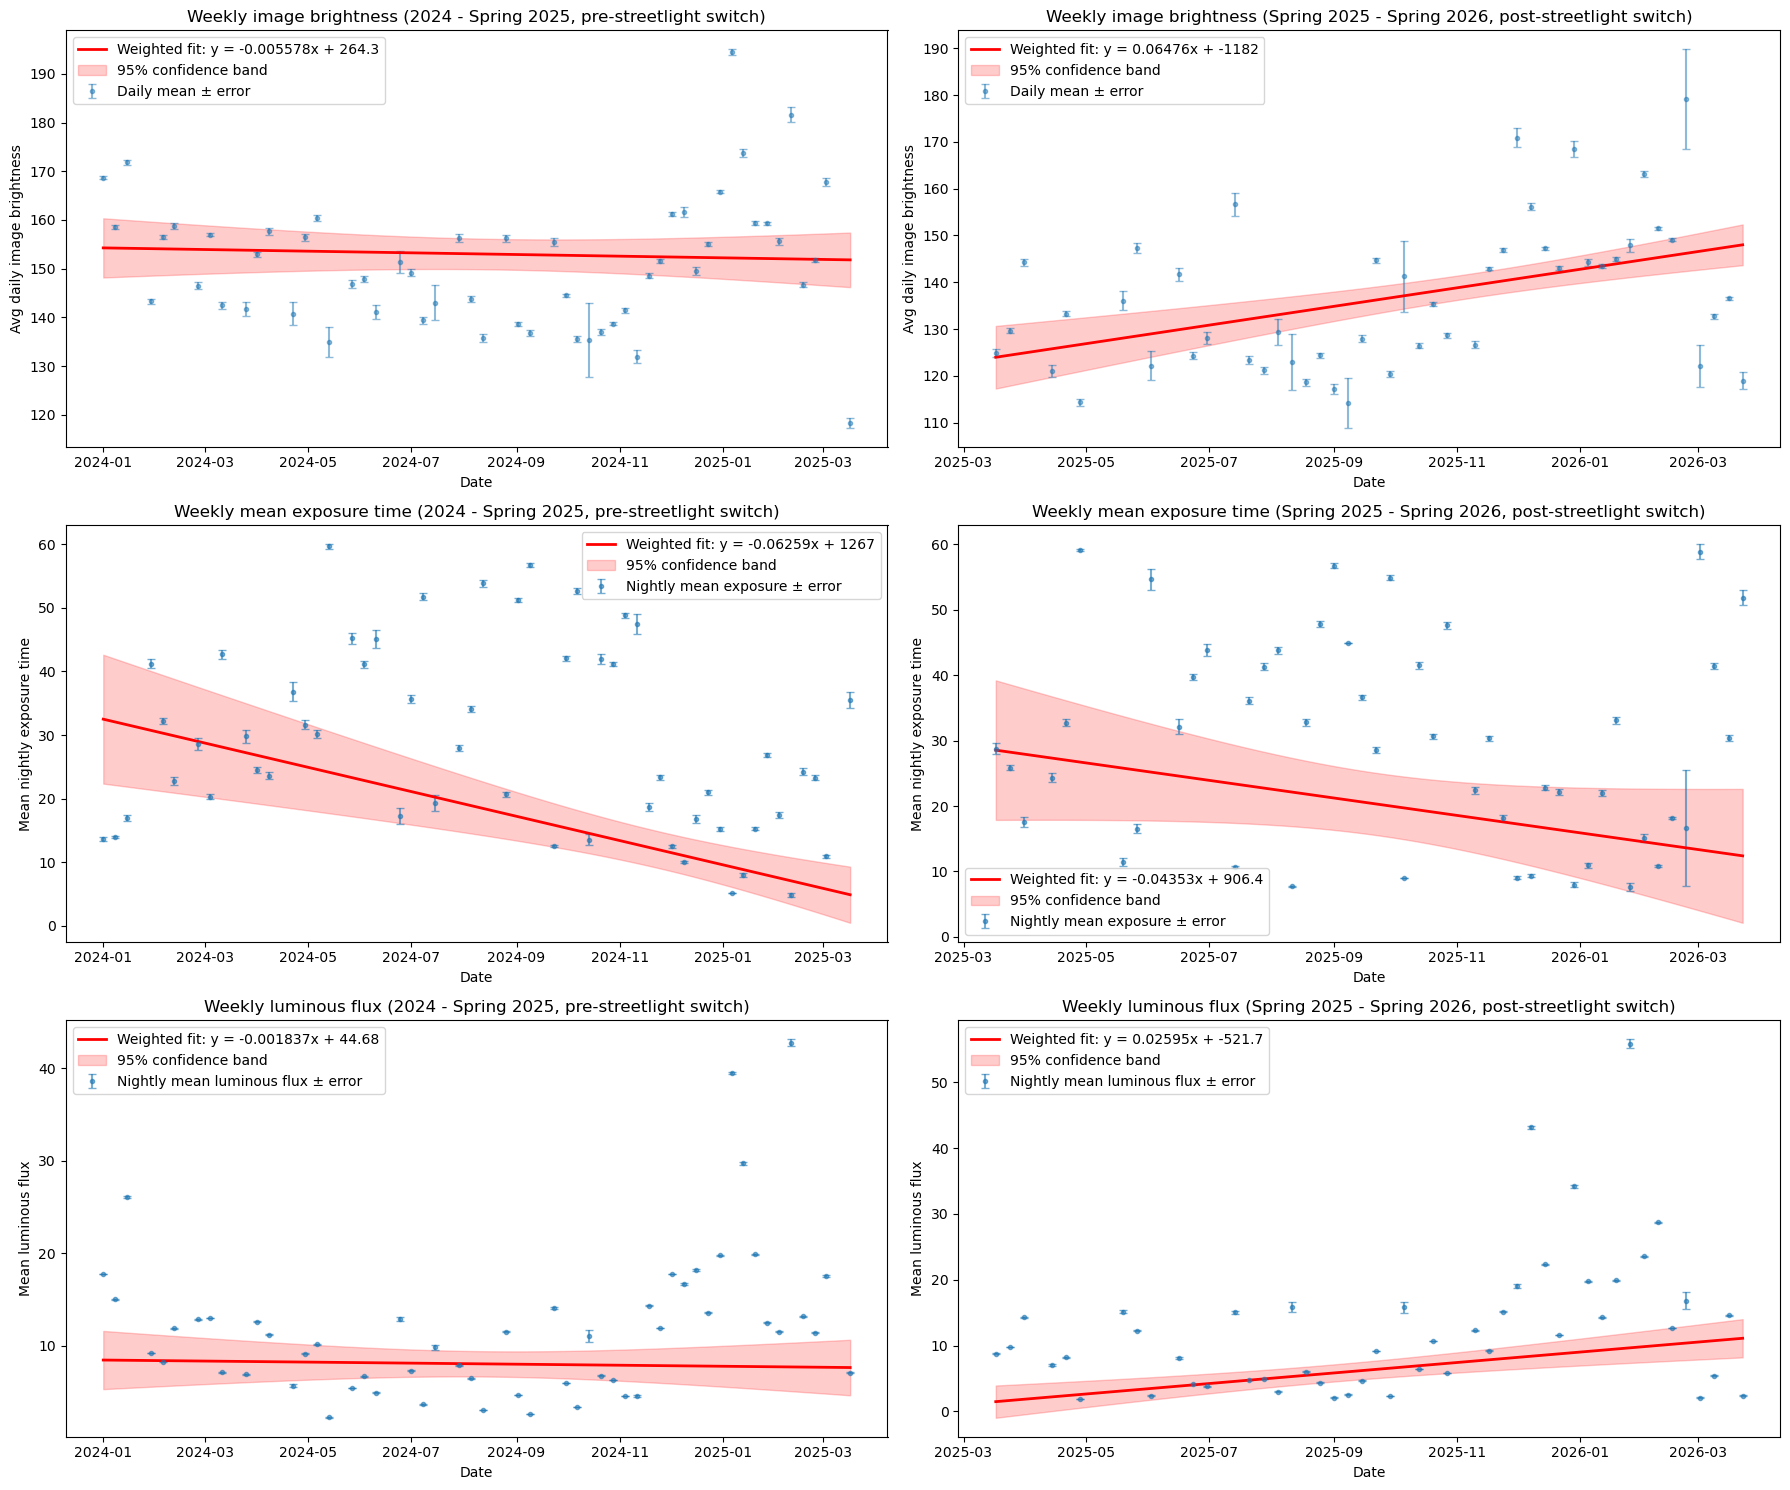

In [71]:
plot_graph(period="W")

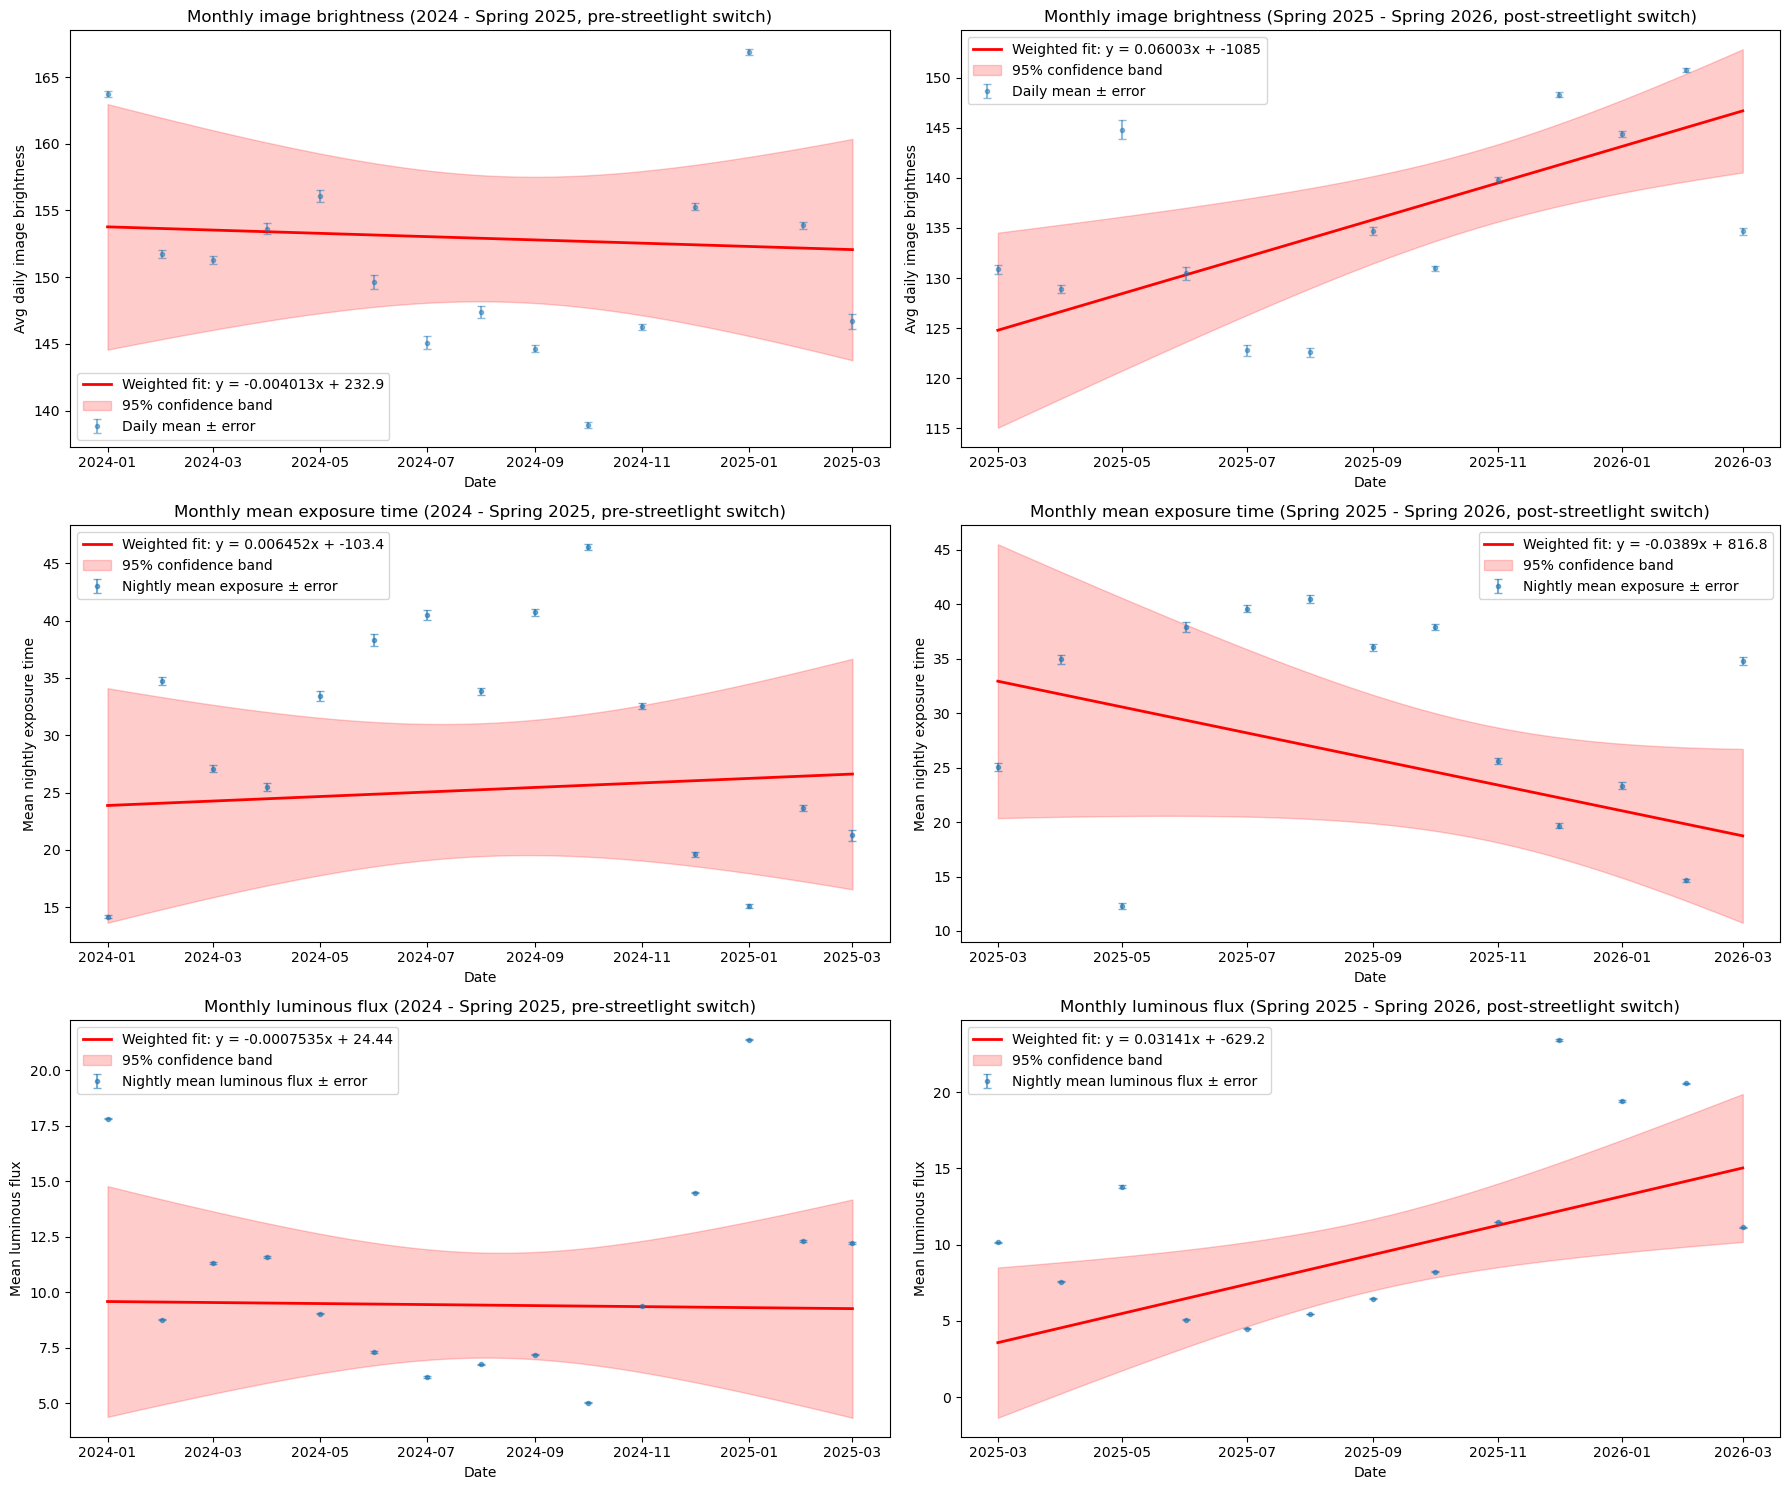

In [72]:
plot_graph(period="M")
